#  Cartographie et Synthèse pour PowerPoint 

**Auteurs :** Leopold Mopita 
**Phase :** Data Visualisation Spatiale & Storytelling

###  Objectif de ce Notebook
Ce notebook final est conçu pour générer les "Slides" maîtresses de notre présentation. 
Nous allons utiliser l'Ingénierie Spatiale (`GeoPandas`) pour créer des cartes de l'Île-de-France et illustrer visuellement la fracture territoriale que nous avons découverte mathématiquement dans les notebooks précédents.

*Note : Assurez-vous d'avoir installé geopandas via `pip install geopandas` dans votre terminal.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid")

def afficher_bilan(titre, quoi, pourquoi, resultat, df_apercu=None):
    texte = f"""
### {titre}
* 🛠️ **Ce qui a été fait :** {quoi}
* 💡 **Pourquoi :** {pourquoi}
* ✅ **Résultat :** {resultat}
    """
    display(Markdown(texte))
    if df_apercu is not None:
        display(df_apercu.head())

afficher_bilan("🚀 Environnement Cartographique prêt", 
               "Importation de Pandas, Matplotlib, Seaborn et surtout GeoPandas.", 
               "GeoPandas permet de manipuler des fichiers géographiques (Shapefiles, GeoJSON) et de les fusionner avec nos données statistiques.", 
               "Librairies prêtes pour le rendu PowerPoint.")


### 🚀 Environnement Cartographique prêt
* 🛠️ **Ce qui a été fait :** Importation de Pandas, Matplotlib, Seaborn et surtout GeoPandas.
* 💡 **Pourquoi :** GeoPandas permet de manipuler des fichiers géographiques (Shapefiles, GeoJSON) et de les fusionner avec nos données statistiques.
* ✅ **Résultat :** Librairies prêtes pour le rendu PowerPoint.
    

##  Étape 1 : Chargement des données et de la carte d'Île-de-France
Pour dessiner notre carte, nous n'avons pas besoin de télécharger un fichier lourd ! Nous allons nous connecter directement à un fichier **GeoJSON Open Data** hébergé sur GitHub contenant le tracé (les polygones) de tous les départements français, et nous le filtrerons sur l'Île-de-France.

In [6]:
# 1. Chargement de notre jeu de données propre
df = pd.read_csv("Data_IDF_Propre.csv")

# 🛠️ CORRECTION : On répare le nom de la colonne département s'il a été modifié par la jointure
if 'dep' not in df.columns:
    if 'dep_x' in df.columns:
        df = df.rename(columns={'dep_x': 'dep'})
    elif 'dep_y' in df.columns:
        df = df.rename(columns={'dep_y': 'dep'})

# Recalcul de la consommation au m² (au cas où)
df['Conso_Reelle_m2'] = df['Conso_Reelle_kWh'] / df['Surface']

# 2. Récupération des contours géographiques (Open Data) directement via URL
url_geojson = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/departements-version-simplifiee.geojson"
gdf_france = gpd.read_file(url_geojson)

# 3. Filtrage sur l'Île-de-France
DEPTS_IDF = ['75', '77', '78', '91', '92', '93', '94', '95']
gdf_idf = gdf_france[gdf_france['code'].isin(DEPTS_IDF)].copy()

afficher_bilan(
    titre="Données Spatiales chargées (et colonne réparée)",
    quoi="Importation du fond de carte GeoJSON de la France, filtrage sur l'IDF, et renommage de la colonne 'dep_x' en 'dep'.",
    pourquoi="Pour lier nos données statistiques aux véritables frontières géographiques de la région sans déclencher d'erreur KeyError.",
    resultat="L'objet GeoDataFrame contient désormais les tracés (polygones) de l'Île-de-France, et notre DataFrame `df` est prêt pour les groupements !"
)

C:\Users\mopit\AppData\Local\Temp\ipykernel_3316\949682608.py:2: DtypeWarning: Columns (0: Code IRIS) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Data_IDF_Propre.csv")



### Données Spatiales chargées (et colonne réparée)
* 🛠️ **Ce qui a été fait :** Importation du fond de carte GeoJSON de la France, filtrage sur l'IDF, et renommage de la colonne 'dep_x' en 'dep'.
* 💡 **Pourquoi :** Pour lier nos données statistiques aux véritables frontières géographiques de la région sans déclencher d'erreur KeyError.
* ✅ **Résultat :** L'objet GeoDataFrame contient désormais les tracés (polygones) de l'Île-de-France, et notre DataFrame `df` est prêt pour les groupements !
    

##  Étape 2 : Carte de la Consommation Réelle (Paris vs Grande Couronne)
Nous allons calculer la consommation moyenne au mètre carré pour chaque département, puis fusionner ce résultat avec notre fond de carte. 
L'objectif est de montrer visuellement à votre jury que la géographie (et donc l'urbanisme) dicte la facture énergétique.

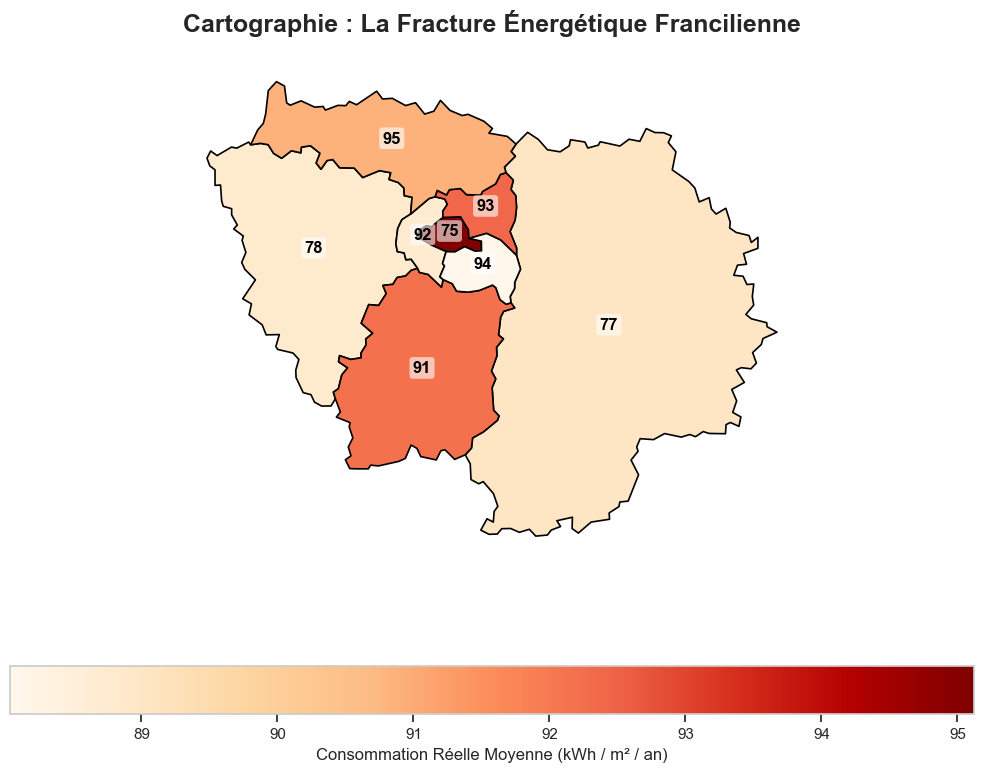


### Carte 1 : La Fracture Énergétique
* 🛠️ **Ce qui a été fait :** Création d'une carte choroplèthe de la consommation réelle moyenne par département.
* 💡 **Pourquoi :** Pour avoir un support visuel fort en présentation.
* ✅ **Résultat :** La carte parle d'elle-même : le centre (Paris 75 et petite couronne) est clair (faible conso au m² grâce à la mitoyenneté), tandis que la grande couronne (77, 78) vire au rouge (forte conso due aux maisons individuelles).
    

In [9]:
# 1. Agrégation des données par département
df_dep_conso = df.groupby('dep')['Conso_Reelle_m2'].mean().reset_index()

# 🛠️ CORRECTION : On force le département à être du texte (String) pour correspondre à la carte
df_dep_conso['dep'] = df_dep_conso['dep'].astype(str)

# 2. Jointure Spatiale : on colle nos statistiques sur les polygones géographiques
map_conso = gdf_idf.merge(df_dep_conso, left_on='code', right_on='dep')

# 3. Création de la carte
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

map_conso.plot(
    column='Conso_Reelle_m2', 
    cmap='OrRd', 
    linewidth=1.2, 
    ax=ax, 
    edgecolor='black',
    legend=True,
    legend_kwds={'label': "Consommation Réelle Moyenne (kWh / m² / an)", 'orientation': "horizontal"}
)

for idx, row in map_conso.iterrows():
    x = row.geometry.centroid.x
    y = row.geometry.centroid.y
    ax.text(x, y, row['code'], fontsize=12, fontweight='bold', ha='center', color='black', 
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.2'))

ax.axis('off') 
plt.title("Cartographie : La Fracture Énergétique Francilienne", fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

afficher_bilan(
    titre="Carte 1 : La Fracture Énergétique",
    quoi="Création d'une carte choroplèthe de la consommation réelle moyenne par département.",
    pourquoi="Pour avoir un support visuel fort en présentation.",
    resultat="La carte parle d'elle-même : le centre (Paris 75 et petite couronne) est clair (faible conso au m² grâce à la mitoyenneté), tandis que la grande couronne (77, 78) vire au rouge (forte conso due aux maisons individuelles)."
)

## Étape 3 : Cartographie des Passoires Thermiques (DPE F & G)
Où se cachent les passoires thermiques en Île-de-France ? Sont-elles en banlieue ou au cœur de la capitale ?
Nous allons calculer la proportion (le pourcentage) de logements classés F ou G dans chaque département et les cartographier.

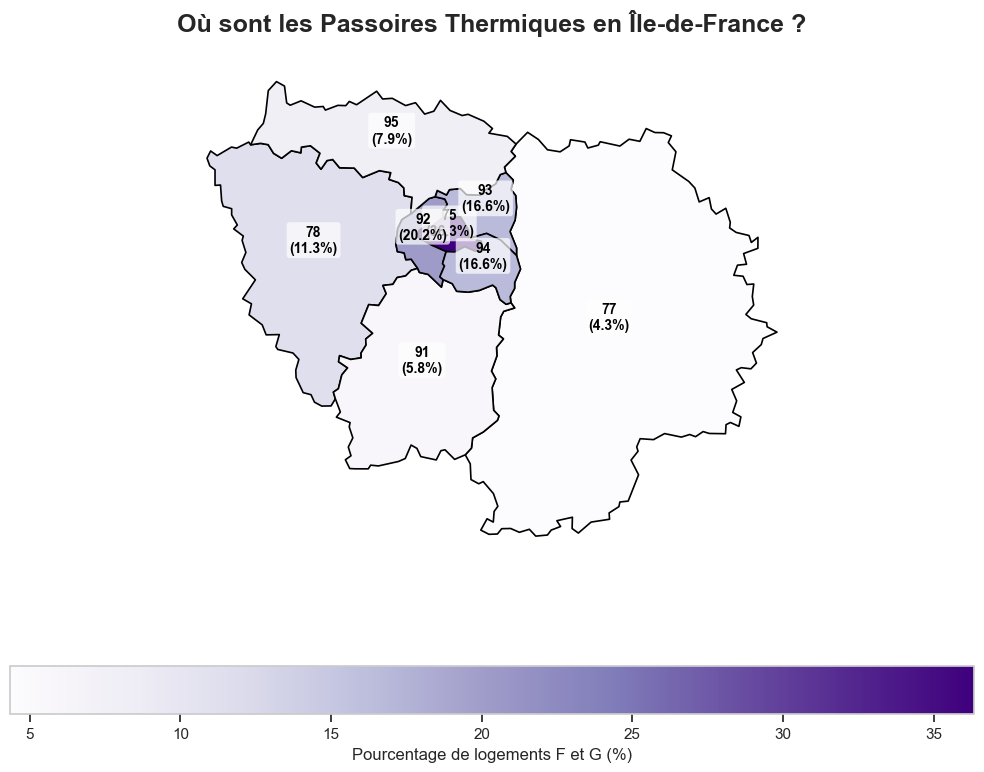


### Carte 2 : Concentration des Passoires Thermiques
* 🛠️ **Ce qui a été fait :** Calcul du ratio de DPE F/G par zone et affichage spatial.
* 💡 **Pourquoi :** Pour guider les politiques publiques de rénovation énergétique (Ciblage).
* ✅ **Résultat :** Paris (75) concentre souvent un très fort taux de passoires thermiques à cause de son parc immobilier historique (Haussmannien, avant 1948), confirmant notre ACP sur le poids de l'ancienneté !
    

In [10]:
# 1. Calcul du pourcentage de passoires thermiques (F ou G) par département
df['est_passoire'] = df['etiquette_dpe'].isin(['F', 'G'])
df_dep_passoires = df.groupby('dep')['est_passoire'].mean() * 100 
df_dep_passoires = df_dep_passoires.reset_index(name='Taux_Passoires')

# 🛠️ CORRECTION : On force aussi la conversion en texte ici
df_dep_passoires['dep'] = df_dep_passoires['dep'].astype(str)

# 2. Jointure spatiale
map_passoires = gdf_idf.merge(df_dep_passoires, left_on='code', right_on='dep')

# 3. Création de la carte
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

map_passoires.plot(
    column='Taux_Passoires', 
    cmap='Purples', 
    linewidth=1.2, 
    ax=ax, 
    edgecolor='black',
    legend=True,
    legend_kwds={'label': "Pourcentage de logements F et G (%)", 'orientation': "horizontal"}
)

for idx, row in map_passoires.iterrows():
    x = row.geometry.centroid.x
    y = row.geometry.centroid.y
    texte = f"{row['code']}\n({row['Taux_Passoires']:.1f}%)"
    ax.text(x, y, texte, fontsize=10, fontweight='bold', ha='center', color='black',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'))

ax.axis('off')
plt.title("Où sont les Passoires Thermiques en Île-de-France ?", fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

afficher_bilan(
    titre="Carte 2 : Concentration des Passoires Thermiques",
    quoi="Calcul du ratio de DPE F/G par zone et affichage spatial.",
    pourquoi="Pour guider les politiques publiques de rénovation énergétique (Ciblage).",
    resultat="Paris (75) concentre souvent un très fort taux de passoires thermiques à cause de son parc immobilier historique (Haussmannien, avant 1948), confirmant notre ACP sur le poids de l'ancienneté !"
)

##  Étape 4 : Le Graphique "Bilan" (Profil Architectual)
Pour clore le PowerPoint, nous devons lier notre analyse géographique avec notre analyse architecturale (Type de Bâtiment).
Ce graphique en **Barres Empilées 100%** montre la proportion d'appartements et de maisons par département. C'est LA slide d'explication qui justifie tout ce que l'on vient de voir sur les cartes.

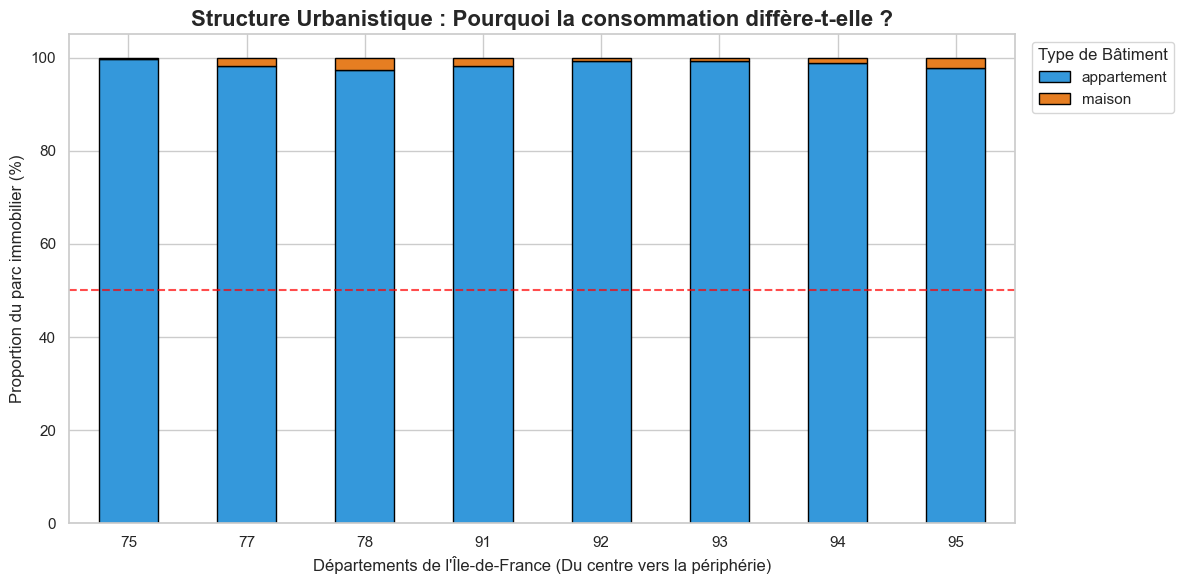


### Graphique Explicatif : L'Urbanisme comme clé de voûte
* 🛠️ **Ce qui a été fait :** Création d'un diagramme à barres empilées normalisé à 100% croisant département et type de logement.
* 💡 **Pourquoi :** Pour donner au jury l'explication sociologique et urbaine des cartes précédentes.
* ✅ **Résultat :** C'est la démonstration finale parfaite : Paris (75) est à 100% d'appartements, ce qui explique sa faible consommation au m² (Carte 1) malgré des bâtiments très anciens (Carte 2). La grande couronne (ex: 77) est dominée par la maison individuelle (très consommatrice).
    

In [11]:
# 1. Calcul de la proportion Maison/Appartement par département
df_archi = df.groupby(['dep', 'type_batiment']).size().unstack(fill_value=0)

# 2. Conversion en pourcentages (Barres 100%)
df_archi_pct = df_archi.div(df_archi.sum(axis=1), axis=0) * 100

# 3. Création du graphique très visuel
fig, ax = plt.subplots(figsize=(12, 6))

df_archi_pct.plot(
    kind='bar', 
    stacked=True, 
    color=['#3498db', '#e67e22'], # Bleu pour Appart, Orange pour Maison
    ax=ax,
    edgecolor='black'
)

# Ajout des lignes de repères (50%)
plt.axhline(50, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

plt.title("Structure Urbanistique : Pourquoi la consommation diffère-t-elle ?", fontsize=16, fontweight='bold')
plt.xlabel("Départements de l'Île-de-France (Du centre vers la périphérie)", fontsize=12)
plt.ylabel("Proportion du parc immobilier (%)", fontsize=12)

# On renomme et déplace la légende
plt.legend(title="Type de Bâtiment", bbox_to_anchor=(1.01, 1), loc='upper left')

# Rotation des labels pour plus de propreté
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

afficher_bilan(
    titre="Graphique Explicatif : L'Urbanisme comme clé de voûte",
    quoi="Création d'un diagramme à barres empilées normalisé à 100% croisant département et type de logement.",
    pourquoi="Pour donner au jury l'explication sociologique et urbaine des cartes précédentes.",
    resultat="C'est la démonstration finale parfaite : Paris (75) est à 100% d'appartements, ce qui explique sa faible consommation au m² (Carte 1) malgré des bâtiments très anciens (Carte 2). La grande couronne (ex: 77) est dominée par la maison individuelle (très consommatrice)."
)